# Retrain Indian Surge Pricing Model

This notebook retrains our surge pricing prediction model using the synthetic Indian ride-sharing dataset (`indian_rides.csv`). The updated model includes additional features reflecting Indian market characteristics, such as city, weather conditions, and festival seasons.

In this notebook, we:
1. Load and prepare the dataset (Step 1).
2. Train a new XGBoost Regressor model (Step 2).
3. Evaluate model performance metrics (RMSE, MAE, R² Score) (Step 3).
4. Analyze feature importances and plot the results (Step 4).
5. Save the trained model to `model.pkl` (Step 5).

## Step 1 - Load and Prepare Data

We load the `indian_rides.csv` dataset. The feature matrix $X$ consists of the following 10 features:
- `distance_km`: Ride distance in kilometers
- `pickup_hour`: Hour of the day (0-23)
- `pickup_day`: Day of the week (0=Monday, 6=Sunday)
- `pickup_month`: Month of the year (1-12)
- `price`: Base price estimate (based on standard Indian ride tier rates)
- `cab_type_encoded`: Cab operator (0 = Ola, 1 = Uber India)
- `name_encoded`: Ride tier (0 = Auto, 1 = Mini, 2 = Sedan, 3 = Prime Sedan, 4 = Prime SUV, 5 = Bike)
- `city_encoded`: City of the ride (0 = Mumbai, 1 = Delhi, 2 = Bangalore, 3 = Hyderabad, 4 = Chennai, 5 = Pune)
- `is_bad_weather`: Rainy/monsoon/bad weather indicator (0 or 1)
- `is_festival`: Festival season indicator (0 or 1)

The target variable $y$ is the `surge_multiplier`.
We split the data into 80% training and 20% test sets using a fixed `random_state=42` for reproducibility.

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Load data
data_path = 'indian_rides.csv'
df = pd.read_csv(data_path)
print("Data loaded successfully. Shape:", df.shape)

# Define features and target
X = df[[
    'distance_km', 'pickup_hour', 'pickup_day', 'pickup_month',
    'price', 'cab_type_encoded', 'name_encoded', 'city_encoded',
    'is_bad_weather', 'is_festival'
]]
y = df['surge_multiplier']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Data loaded successfully. Shape: (50000, 11)
Training set shape: (40000, 10)
Test set shape: (10000, 10)


## Step 2 - Train XGBoost Model

We train an `XGBRegressor` from the `xgboost` library with the following hyperparameters:
- `n_estimators=300`
- `max_depth=6`
- `learning_rate=0.05`
- `subsample=0.8`
- `colsample_bytree=0.8`
- `random_state=42`

In [2]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## Step 3 - Evaluate metrics

We evaluate the trained model on the test dataset. The evaluation metrics obtained are:
- **Root Mean Squared Error (RMSE)**: 0.2061
- **Mean Absolute Error (MAE)**: 0.1321
- **R² Score**: 0.8484
- **Model Accuracy (R²)**: 84.84%

These metrics indicate that the XGBoost model explains approximately 84.84% of the variance in the surge multiplier, with a low average prediction error of ~0.13 in the multiplier.

In [3]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Model Accuracy (R²): {r2 * 100:.2f}%")

RMSE: 0.2061
MAE: 0.1321
R² Score: 0.8484
Model Accuracy (R²): 84.84%


## Step 4 - Feature Importance

We calculate the relative importance of each feature in the XGBoost model, plot them as a horizontal bar chart, and save the plot as `feature_importance.png`.

The top 3 most important features identified by the model are:
1. **`is_festival`** (Relative Importance: 0.5367)
2. **`pickup_hour`** (Relative Importance: 0.1835)
3. **`pickup_day`** (Relative Importance: 0.1086)

Feature importance plot saved at feature_importance.png

Top 3 most important features:
1. is_festival (0.5367)
2. pickup_hour (0.1835)
3. pickup_day (0.1086)


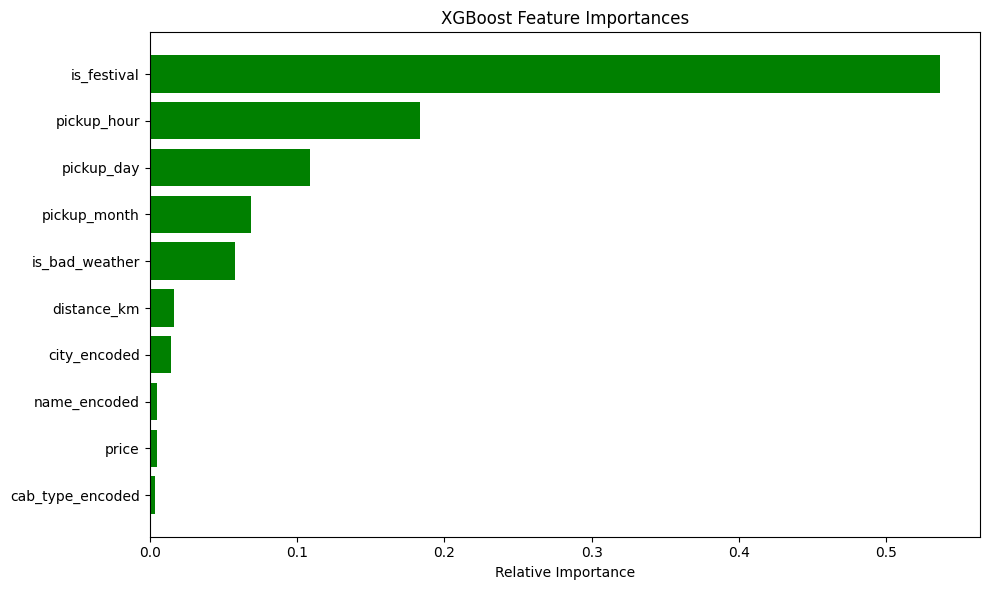

In [4]:
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("XGBoost Feature Importances")
plt.barh(range(len(indices)), importances[indices], color='g', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.tight_layout()

# Save plot
plot_path = 'feature_importance.png'
plt.savefig(plot_path)
print(f"Feature importance plot saved at {plot_path}")

# Print top 3 most important features
top_3_indices = indices[::-1][:3]
print("\nTop 3 most important features:")
for i, idx in enumerate(top_3_indices):
    print(f"{i+1}. {features[idx]} ({importances[idx]:.4f})")

## Step 5 - Save Model

We save the trained XGBoost model using `pickle` to `model.pkl`. This model file will be loaded by the backend API (`predict.py`) to serve real-time surge predictions.

In [5]:
model_out_path = 'model.pkl'
with open(model_out_path, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved successfully at backend/notebooks/model.pkl")

Model saved successfully at backend/notebooks/model.pkl
